### Load Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
def generate_data(n, r=0, inv=False):
    x = np.arange(-n // 2, n // 2)
    y = np.array([0 if i < 0 else 1 for i in x])
    if inv:
        flip = np.random.rand(n) < n//2
        y[flip] = 1 - y[flip]
    if r:
        idx = np.random.choice(n, size=min(r, n), replace=False)
        y[idx] = 1 - y[idx]
    plt.scatter(x[y == 0], y[y == 0], label="Class 0", color="red")
    plt.scatter(x[y == 1], y[y == 1], label="Class 1", color="green")
    plt.yticks([0, 1])
    plt.grid()
    plt.legend()
    plt.show()
    return x, y

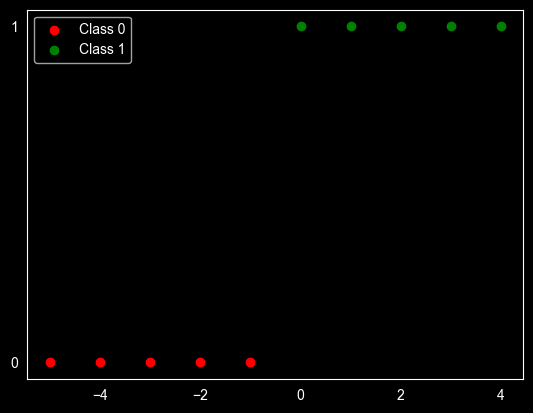

In [2]:
X1, y1 = generate_data(10)

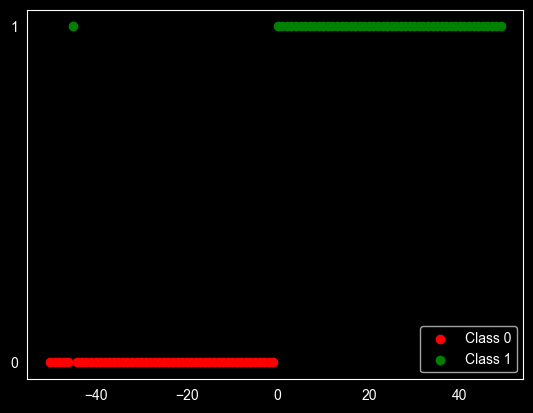

In [3]:
X2, y2 = generate_data(100, r = 1)

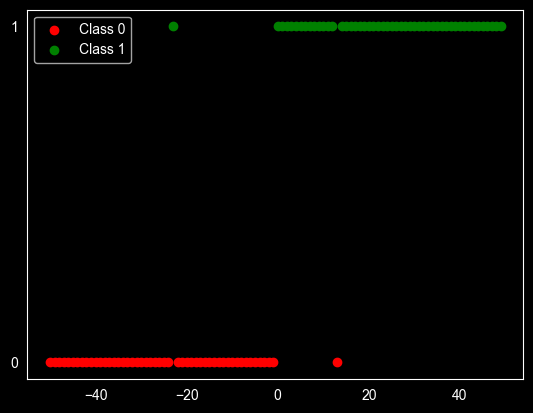

In [4]:
X3, y3 = generate_data(100, r=2)

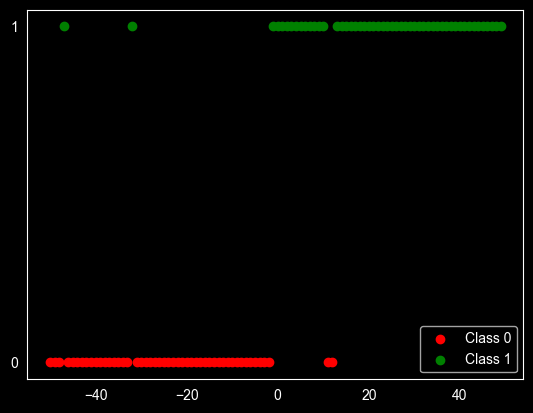

In [5]:
X4, y4 = generate_data(100, r=5)

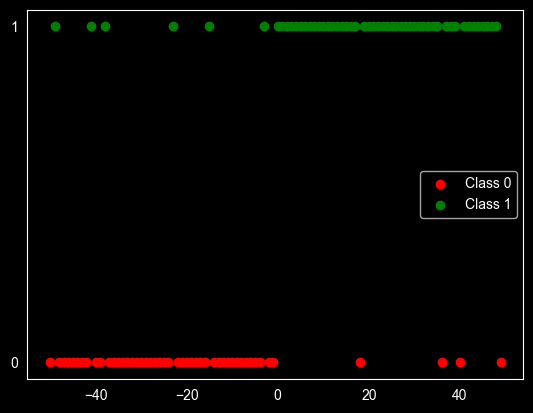

In [6]:
X5, y5 = generate_data(100, r=10)

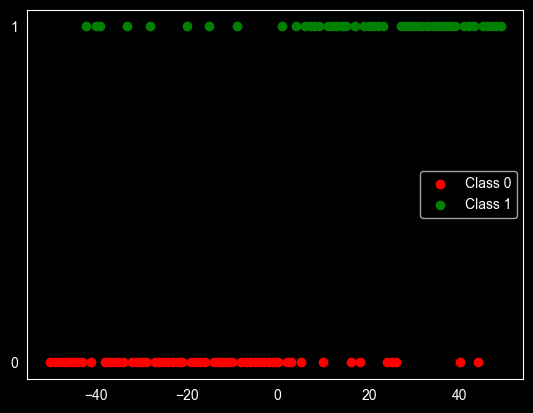

In [7]:
X6, y6 = generate_data(100, r=20)

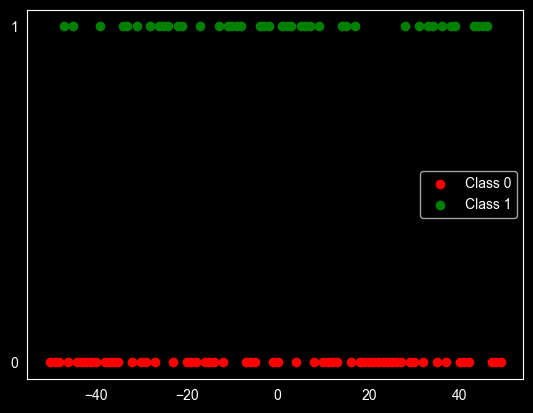

In [8]:
X7, y7 = generate_data(100, r=50)

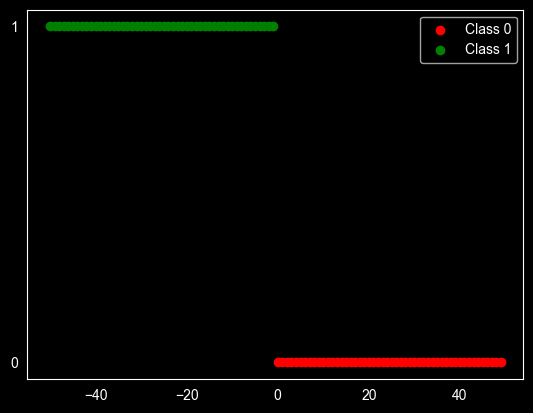

In [9]:
X8, y8 = generate_data(100, inv=True)

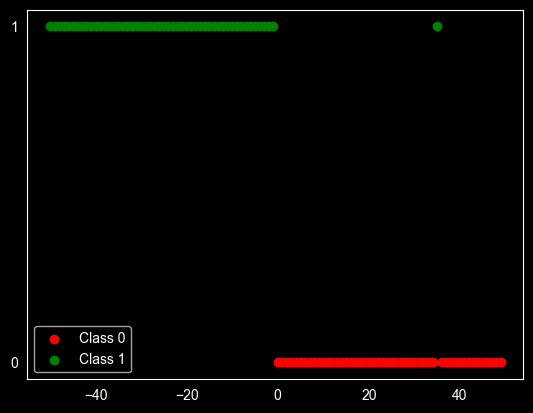

In [10]:
X9, y9 = generate_data(100, inv=True, r=1)

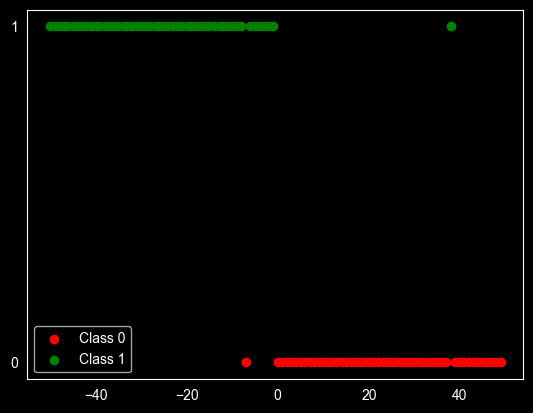

In [11]:
X10, y10 = generate_data(100, inv=True, r=2)

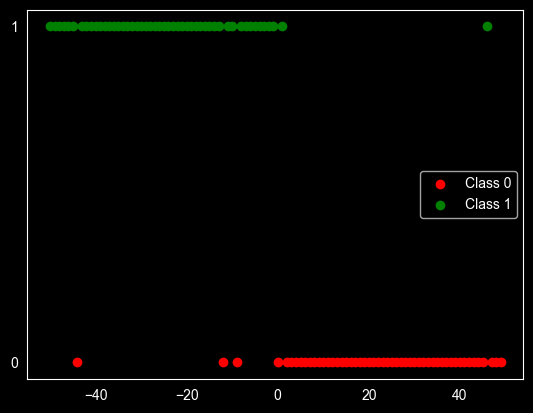

In [12]:
X11, y11 = generate_data(100, inv=True, r=5)

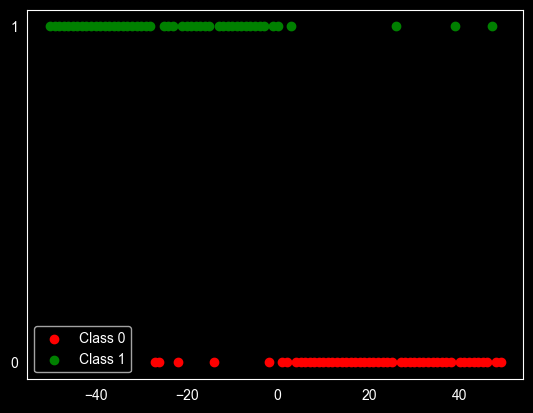

In [13]:
X12, y12 = generate_data(100, inv=True, r=10)

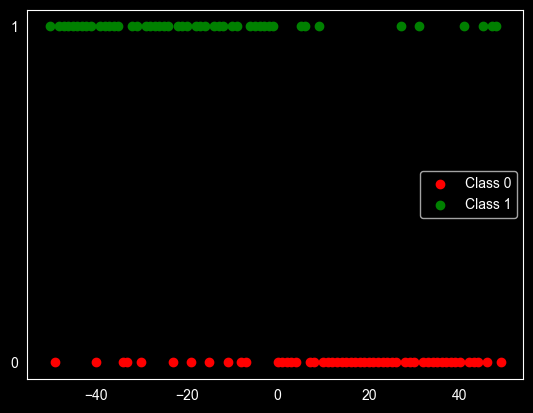

In [14]:
X13, y13 = generate_data(100, inv=True, r=20)

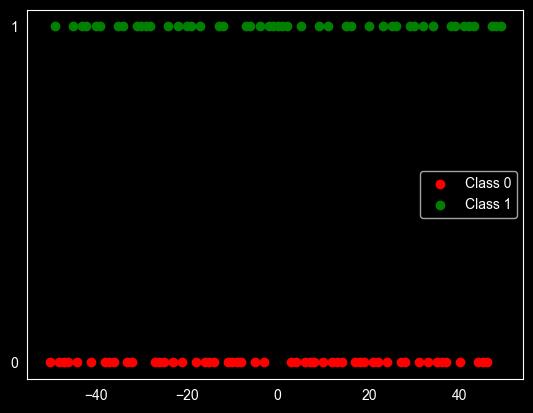

In [15]:
X14, y14 = generate_data(100, inv=True, r=50)

### Utils

In [16]:
import math
def sigmoid(x):
    return 1 / (1+(math.e**(-x)))

In [17]:
def predict(x, m, c, thresh=0.5):
    return int(sigmoid(m * x + c) > thresh)

In [18]:
def log_loss(y, y_pred): # Binary Cross Entropy, Cross Entropy, Binary Log Loss, Log Loss, Logistic Loss, Negative Log-Likelihood, etc
    s = 0
    m = len(y)
    for yi, pi in zip(y, y_pred):
        if pi == 0:
            pi = 0.0000000001
        if pi == 1:
            pi = 1 - 0.0000000001
        s += yi*math.log(pi) + (1-yi)*math.log(1-pi)
    return -1/m * s

In [19]:
def derivative_loss(X, y, p):
    m = len(y)
    return (X.T @ (p - y)) / m

In [20]:
def confusion_matrix(y, y_pred):
    TP = 0
    TN = 0
    FP = 0
    FN = 0
    for i, j in zip(y, y_pred):
        if i == 0 and i == j:
            TN += 1
        elif i == 1 and i == j:
            TP += 1
        elif i == 0 and i!=j:
            FP += 1
        elif i == 1 and i!=j:
            FN += 1
    return TP, TN, FP, FN

In [21]:
def Accuracy(y, y_pred):
    TP, TN, FP, FN = confusion_matrix(y, y_pred)
    if len(y) == 0:
        return 0
    acc = (TP + TN) / (TP + TN + FP + FN)
    return round(acc, 4)

In [22]:
def ErrorRate(y, y_pred):
    er = 1- Accuracy(y, y_pred)
    return round(er, 4)

In [23]:
def Precision(y, y_pred):
    TP, TN, FP, FN = confusion_matrix(y, y_pred)
    if TP + FP == 0:
        return 0
    p = TP / (TP + FP)
    return round(p, 4)

In [24]:
def TPR(y, y_pred): # Recall, Sensitivity, True Positive Rate (TPR)
    TP, TN, FP, FN = confusion_matrix(y, y_pred)
    if TP + FN == 0:
        return 0
    tpr = TP / (TP + FN)
    return round(tpr, 4)

In [25]:
def TNR(y, y_pred): # Specificity, True Negative Rate (TNR)
    TP, TN, FP, FN = confusion_matrix(y, y_pred)
    if TN + FP == 0 :
        return 0
    tnr = TN / (TN + FP)
    return round(tnr, 4)

In [26]:
def FPR(y, y_pred): # Fallout, False Positive Rate (FPR) = 1 - TNR
    fpr = 1 - TNR(y, y_pred)
    return round(fpr, 4)

In [27]:
def FNR(y, y_pred): # False Negative Rate (FNR) = 1 - TPR
    fnr = 1 - TPR(y, y_pred)
    return round(fnr, 4)

In [28]:
def F1Score(y, y_pred):
    p = Precision(y, y_pred)
    r = TPR(y, y_pred)
    if p+r == 0:
        return 0
    f1 = (2*p*r)/(p+r)
    return round(f1, 4)

In [29]:
def plot(x, y, m, c):
    plt.scatter(x[y == 0], y[y == 0], label="Class 0", color="red")
    plt.scatter(x[y == 1], y[y == 1], label="Class 1", color="green")
    plt.yticks([0, 1])
    plt.plot(x, [predict(i, m, c) for i in x], "blue")
    plt.grid()
    plt.show()

### Solve by Newton-Raphson Method

In [30]:
def solve_by_newton(x, y, n_epochs=20):
    c = 0
    m = 0
    n = len(y)
    for _ in range(n_epochs):
        p = [sigmoid(x[i] * m + c) for i in range(n)]
        dc = sum(p[i] - y[i] for i in range(n)) / n # dL/dc
        dm = sum((p[i] - y[i]) * x[i] for i in range(n)) / n # dL/dm
        h_cc = sum(p[i] * (1 - p[i]) for i in range(n)) / n
        h_cm = sum(p[i] * (1 - p[i]) * x[i] for i in range(n)) / n
        h_mm = sum(p[i] * (1 - p[i]) * x[i] ** 2 for i in range(n)) / n
        det = h_cc * h_mm - h_cm ** 2
        delta_c = (h_mm * dc - h_cm * dm) / det
        delta_m = (-h_cm * dc + h_cc * dm) / det
        c -= delta_c
        m -= delta_m
    y_pred = [predict(xi, m, c) for xi in x]
    acc = Accuracy(y, y_pred)
    f1 = F1Score(y, y_pred)
    print(f"Slope :", round(m, 4), "  y-Intercept :", round(c, 4),
          "  Accuracy :", acc, "  F1-Score :", f1, )
    plot(x, y, m, c)

Slope : 34.1022   y-Intercept : 17.0511   Accuracy : 1.0   F1-Score : 1.0


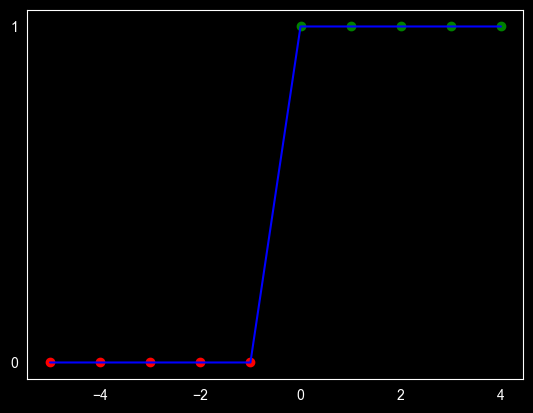

In [31]:
# Solve for Data 1
solve_by_newton(X1, y1)

Slope : 0.1934   y-Intercept : 0.2901   Accuracy : 0.98   F1-Score : 0.9804


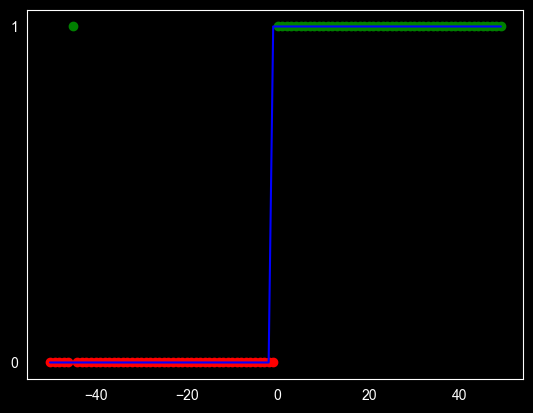

In [32]:
# Solve for Data 2
solve_by_newton(X2, y2)

Slope : 0.2138   y-Intercept : 0.1069   Accuracy : 0.98   F1-Score : 0.98


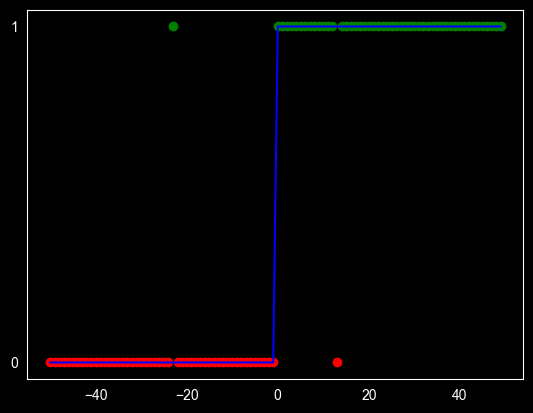

In [33]:
# Solve for Data 3
solve_by_newton(X3, y3)

Slope : 0.126   y-Intercept : 0.1894   Accuracy : 0.96   F1-Score : 0.9608


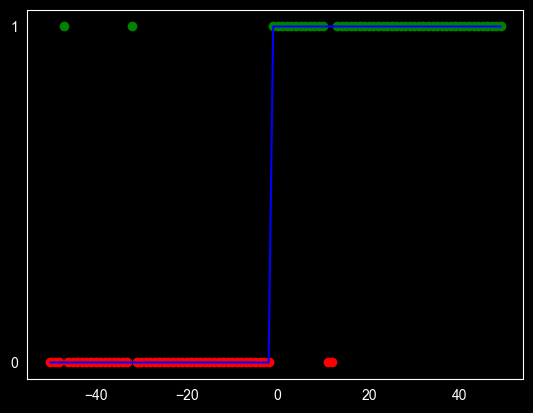

In [34]:
# Solve for Data 4
solve_by_newton(X4, y4)

Slope : 0.0655   y-Intercept : 0.1741   Accuracy : 0.88   F1-Score : 0.8846


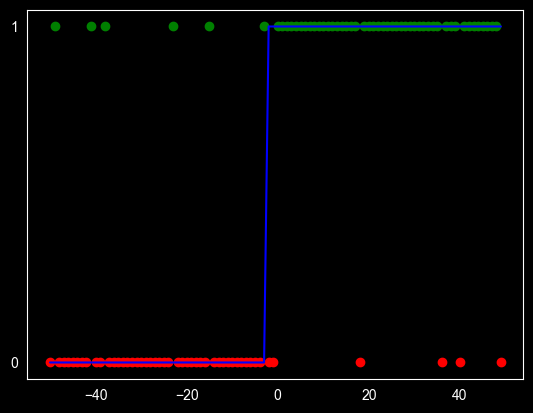

In [35]:
# Solve for Data 5
solve_by_newton(X5, y5)

Slope : 0.0655   y-Intercept : 0.1741   Accuracy : 0.88   F1-Score : 0.8846


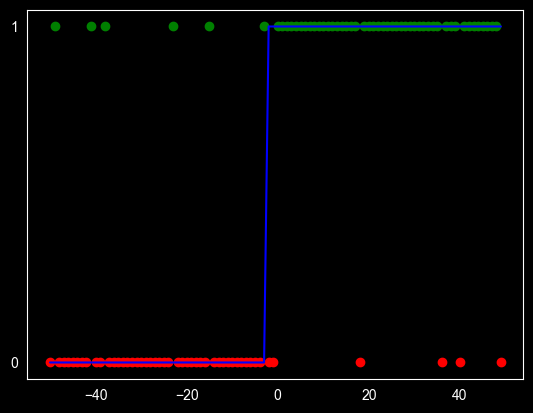

In [36]:
# Solve for Data 5
solve_by_newton(X5, y5)

Slope : 0.05   y-Intercept : -0.2112   Accuracy : 0.81   F1-Score : 0.7912


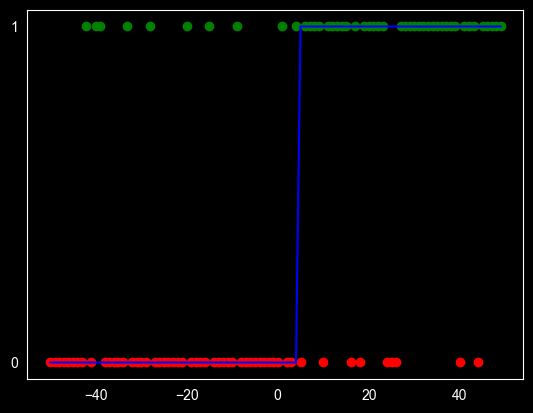

In [37]:
# Solve for Data 6
solve_by_newton(X6, y6)

Slope : 0.0032   y-Intercept : -0.3219   Accuracy : 0.58   F1-Score : 0


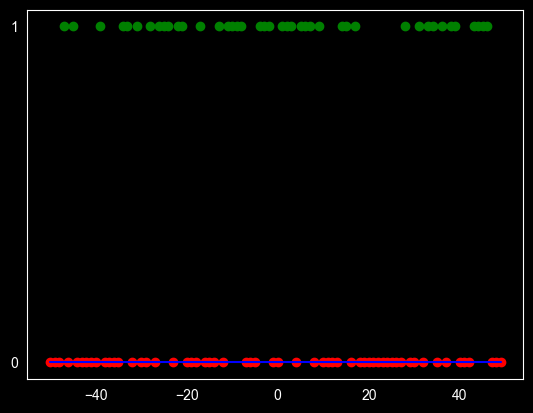

In [38]:
# Solve for Data 7
solve_by_newton(X7, y7)

Slope : -22.7369   y-Intercept : -11.3685   Accuracy : 1.0   F1-Score : 1.0


C:\Users\PRASHANTH N\AppData\Local\Temp\ipykernel_15700\367861518.py:3: RuntimeWarning: overflow encountered in scalar power
  return 1 / (1+(math.e**(-x)))


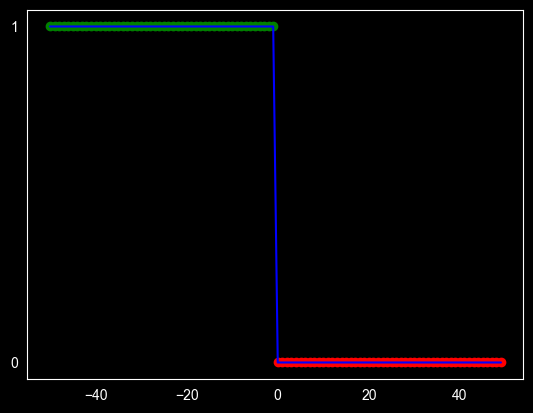

In [39]:
# Solve for Data 8
solve_by_newton(X8, y8)

Slope : -0.2169   y-Intercept : 0.1085   Accuracy : 0.98   F1-Score : 0.9804


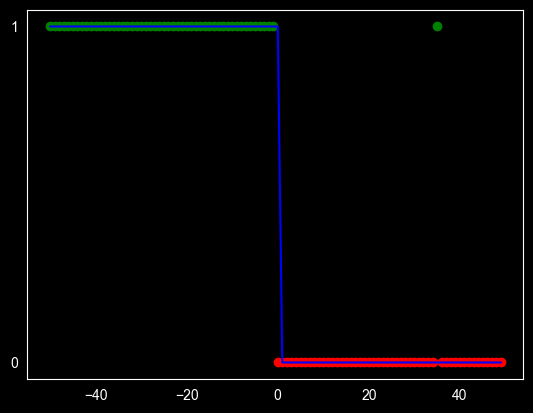

In [40]:
# Solve for Data 9
solve_by_newton(X9, y9)

Slope : -0.1912   y-Intercept : -0.0956   Accuracy : 0.98   F1-Score : 0.98


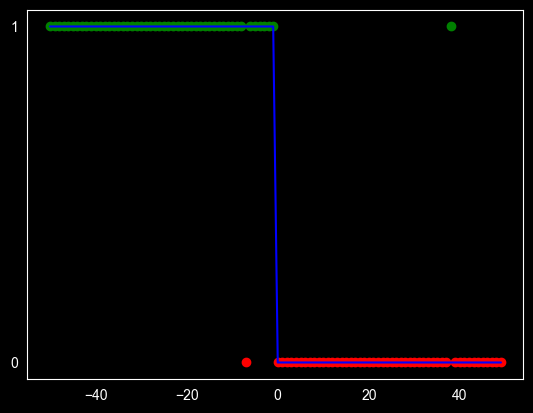

In [41]:
# Solve for Data 10
solve_by_newton(X10, y10)

Slope : -0.1205   y-Intercept : -0.1813   Accuracy : 0.94   F1-Score : 0.9388


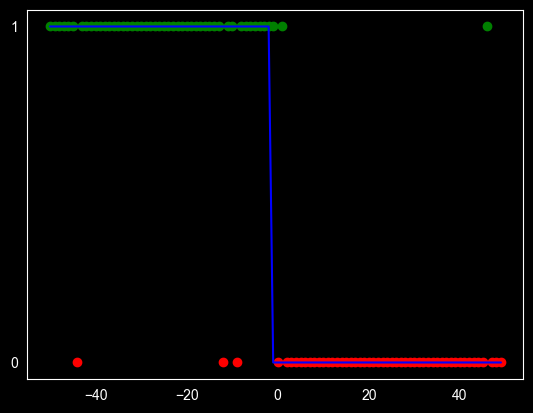

In [42]:
# Solve for Data 11
solve_by_newton(X11, y11)

Slope : -0.0853   y-Intercept : -0.0426   Accuracy : 0.9   F1-Score : 0.9


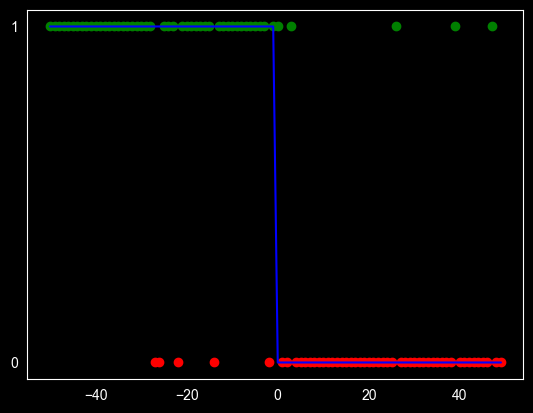

In [43]:
# Solve for Data 12
solve_by_newton(X12, y12)

Slope : -0.0417   y-Intercept : -0.128   Accuracy : 0.77   F1-Score : 0.7579


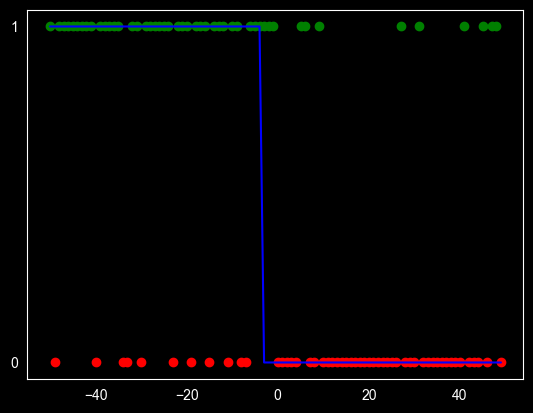

In [44]:
# Solve for Data 13
solve_by_newton(X13, y13)

Slope : 0.0027   y-Intercept : -0.0788   Accuracy : 0.55   F1-Score : 0.3478


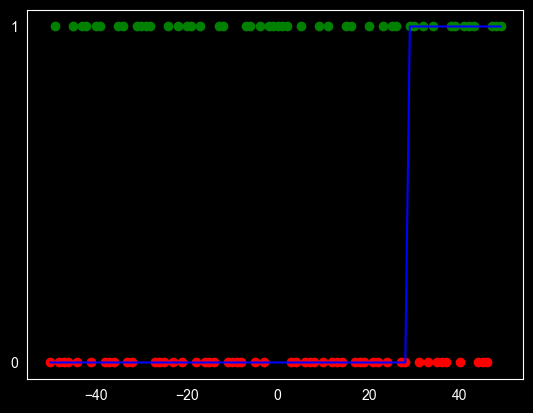

In [45]:
# Solve for Data 14
solve_by_newton(X14, y14)

### Solve by Grid Search

In [46]:
def solve_by_grid_search(x, y, m_range=(-100, 100), c_range=(-100, 100), step=0.1):
    best_loss = float("inf")
    best_m = None
    best_c = None
    for ma in range(m_range[0], m_range[1]):
        m = ma*step
        for ca in range(c_range[0], c_range[1]):
            c = ca*step
            y_pred = [sigmoid(xi * m + c) for xi in x]
            loss = log_loss(y, y_pred)
            if loss < best_loss:
                best_loss = loss
                best_m = m
                best_c = c
    y_pred = [predict(xi, best_m, best_c) for xi in x]
    acc = Accuracy(y, y_pred)
    f1 = F1Score(y, y_pred)
    print(f"Slope :", round(best_m, 4), "  y-Intercept :", round(best_c, 4),
          "  Accuracy :", acc, "  F1-Score :", f1, )
    plot(x, y, best_m, best_c)

Slope : 9.9   y-Intercept : 4.9   Accuracy : 1.0   F1-Score : 1.0


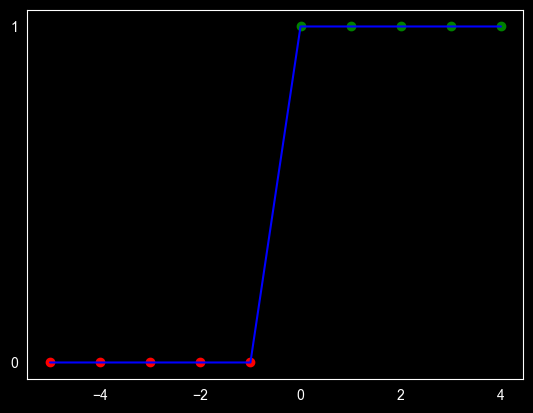

In [47]:
# Solve for Data 1
solve_by_grid_search(X1, y1)

Slope : 0.2   y-Intercept : 0.3   Accuracy : 0.98   F1-Score : 0.9804


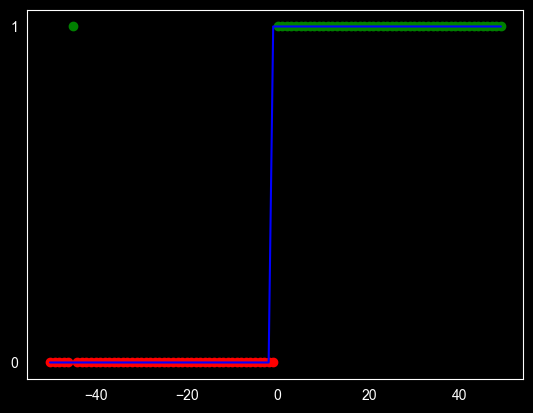

In [48]:
# Solve for Data 2
solve_by_grid_search(X2, y2)

Slope : 0.2   y-Intercept : 0.1   Accuracy : 0.98   F1-Score : 0.98


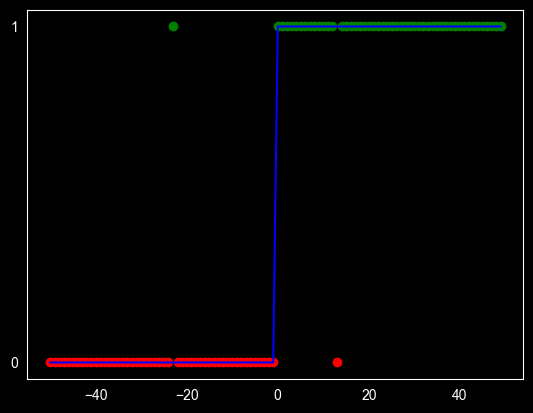

In [49]:
# Solve for Data 3
solve_by_grid_search(X3, y3)

Slope : 0.1   y-Intercept : 0.2   Accuracy : 0.96   F1-Score : 0.9608


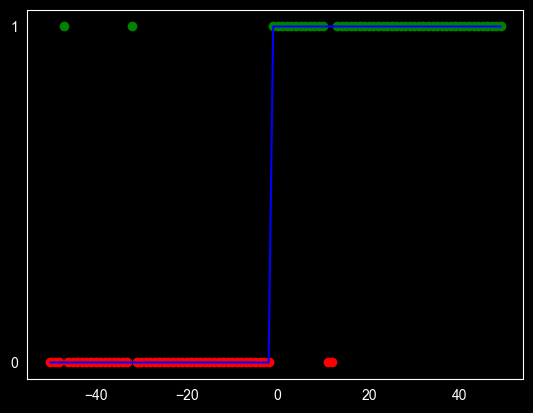

In [50]:
# Solve for Data 4
solve_by_grid_search(X4, y4)

Slope : 0.1   y-Intercept : 0.3   Accuracy : 0.88   F1-Score : 0.8846


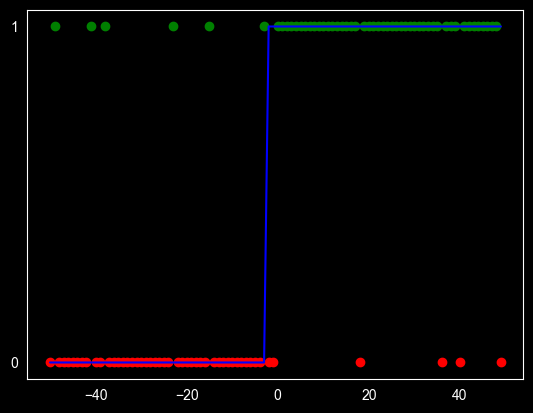

In [51]:
# Solve for Data 5
solve_by_grid_search(X5, y5)

Slope : 0.1   y-Intercept : -0.4   Accuracy : 0.81   F1-Score : 0.7912


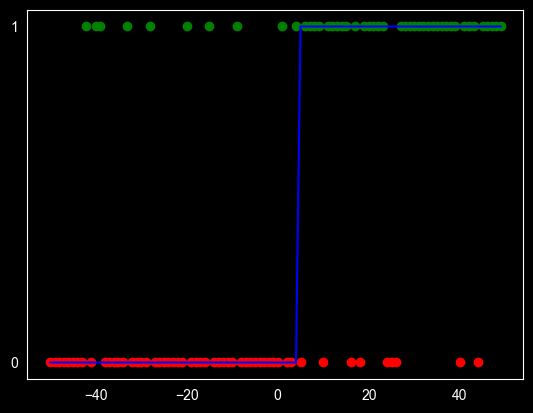

In [52]:
# Solve for Data 6
solve_by_grid_search(X6, y6)

Slope : 0.0   y-Intercept : -0.3   Accuracy : 0.58   F1-Score : 0


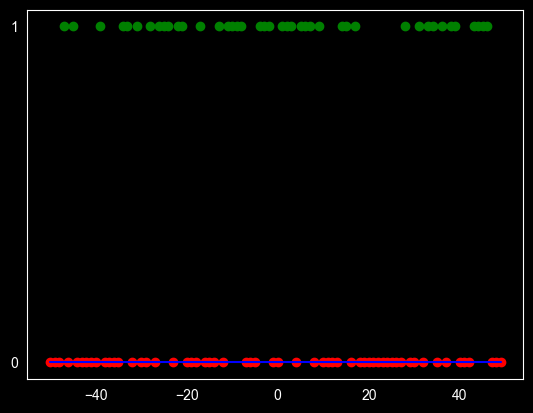

In [53]:
# Solve for Data 7
solve_by_grid_search(X7, y7)

Slope : -10.0   y-Intercept : -5.0   Accuracy : 1.0   F1-Score : 1.0


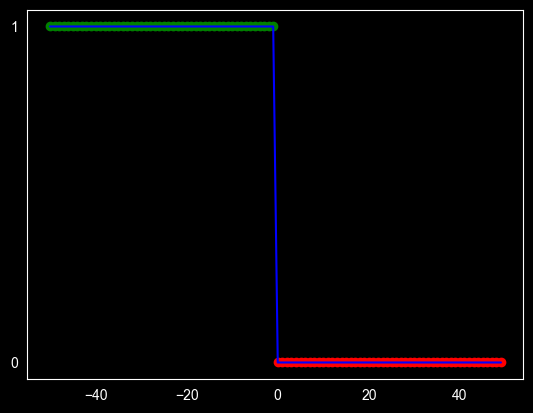

In [54]:
# Solve for Data 8
solve_by_grid_search(X8, y8)

Slope : -0.2   y-Intercept : 0.1   Accuracy : 0.98   F1-Score : 0.9804


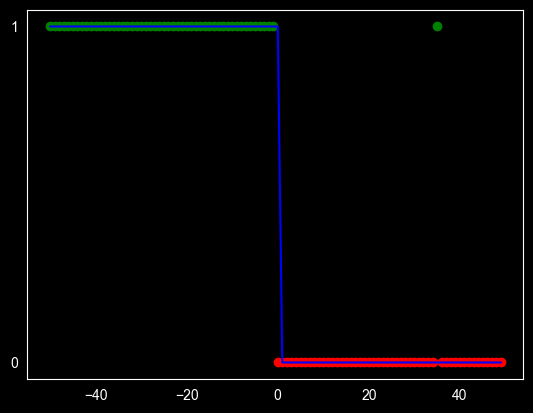

In [55]:
# Solve for Data 9
solve_by_grid_search(X9, y9)

Slope : -0.2   y-Intercept : -0.1   Accuracy : 0.98   F1-Score : 0.98


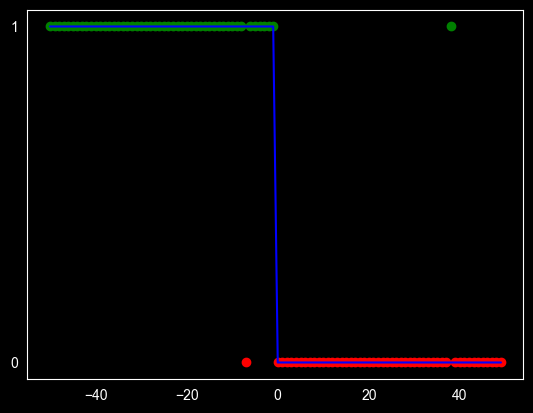

In [56]:
# Solve for Data 10
solve_by_grid_search(X10, y10)

Slope : -0.1   y-Intercept : -0.2   Accuracy : 0.93   F1-Score : 0.9279


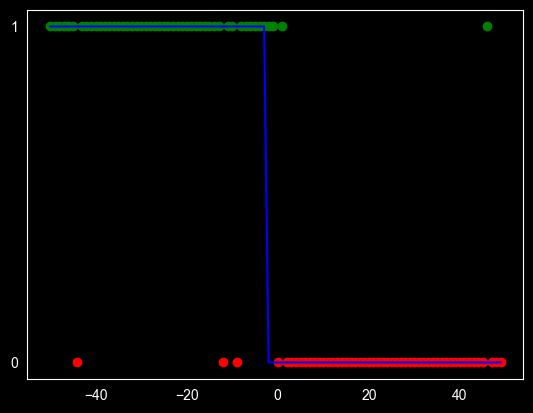

In [57]:
# Solve for Data 11
solve_by_grid_search(X11, y11)

Slope : -0.1   y-Intercept : -0.1   Accuracy : 0.89   F1-Score : 0.8889


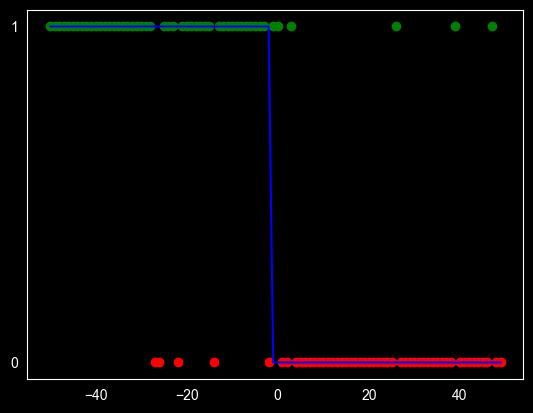

In [58]:
# Solve for Data 12
solve_by_grid_search(X12, y12)

Slope : -0.1   y-Intercept : -0.3   Accuracy : 0.77   F1-Score : 0.7579


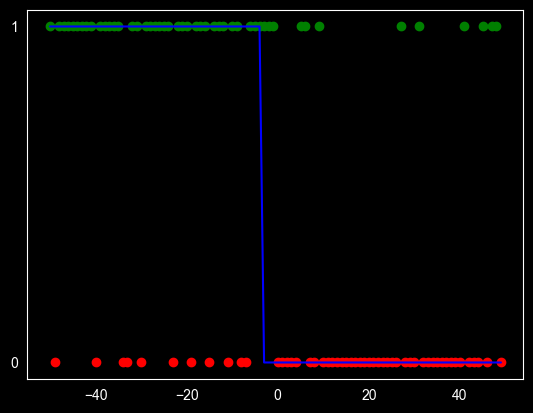

In [59]:
# Solve for Data 13
solve_by_grid_search(X13, y13)

Slope : 0.0   y-Intercept : -0.1   Accuracy : 0.52   F1-Score : 0


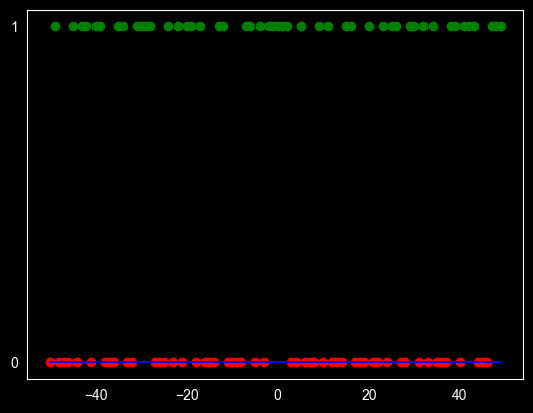

In [60]:
# Solve for Data 14
solve_by_grid_search(X14, y14)

### Solve by Gradient Descent

In [61]:
def solve_by_grad_descent(x, y, n_epochs=10000, eta=0.1):
    c = 0
    m = 0
    n = len(y)
    for _ in range(n_epochs):
        y_pred = [sigmoid(m * x[i] + c) for i in range(n)]
        dc = sum(y_pred[i] - y[i] for i in range(n)) / n
        dm = sum((y_pred[i] - y[i]) * x[i] for i in range(n)) / n
        c -= eta * dc
        m -= eta * dm
    y_pred = [predict(xi, m, c) for xi in x]
    acc = Accuracy(y, y_pred)
    f1 = F1Score(y, y_pred)
    print(f"Slope :", round(m, 4), "  y-Intercept :", round(c, 4),
          "  Accuracy :", acc, "  F1-Score :", f1, )
    plot(x, y, m, c)

Slope : 7.4345   y-Intercept : 3.5081   Accuracy : 1.0   F1-Score : 1.0


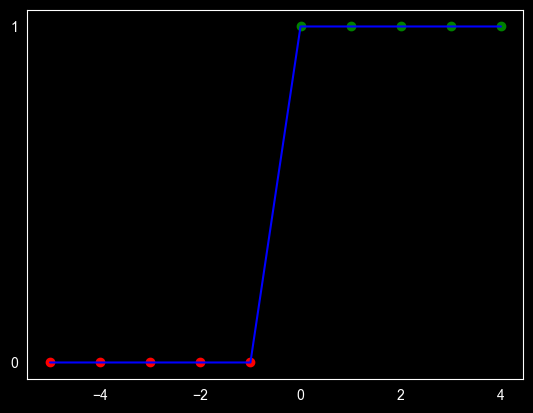

In [62]:
# Solve for Data 1
solve_by_grad_descent(X1, y1)

Slope : 0.1934   y-Intercept : 0.2901   Accuracy : 0.98   F1-Score : 0.9804


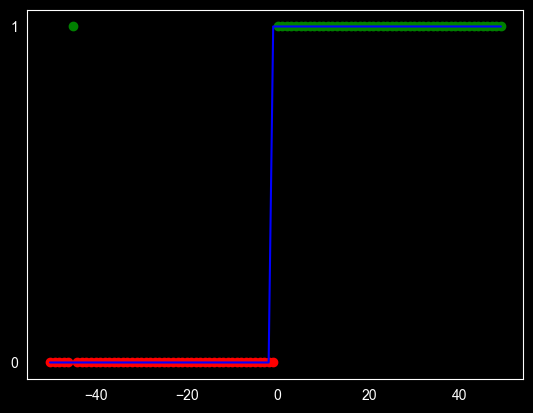

In [63]:
# Solve for Data 2
solve_by_grad_descent(X2, y2)

Slope : 0.2138   y-Intercept : 0.1069   Accuracy : 0.98   F1-Score : 0.98


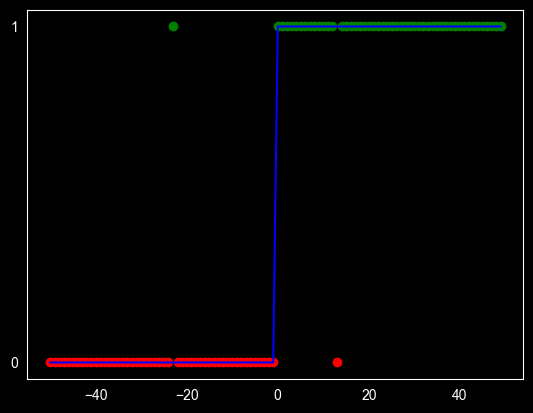

In [64]:
# Solve for Data 3
solve_by_grad_descent(X3, y3)

Slope : 0.126   y-Intercept : 0.1894   Accuracy : 0.96   F1-Score : 0.9608


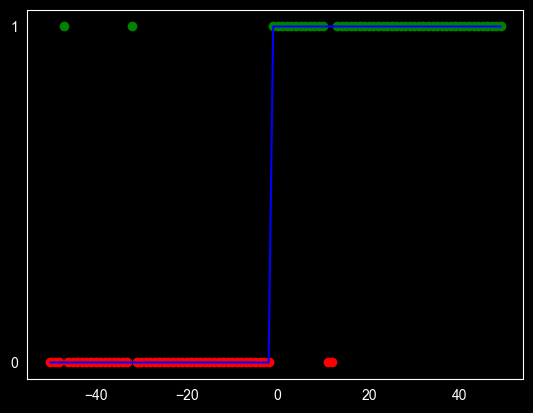

In [65]:
# Solve for Data 4
solve_by_grad_descent(X4, y4)

Slope : 1.8058   y-Intercept : 0.4168   Accuracy : 0.9   F1-Score : 0.902


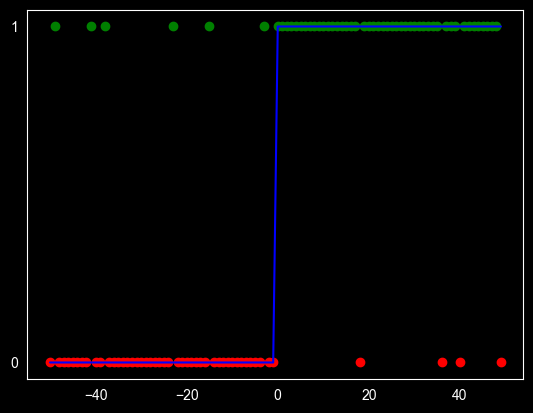

In [66]:
# Solve for Data 5
solve_by_grad_descent(X5, y5)

Slope : 0.5021   y-Intercept : -0.7282   Accuracy : 0.8   F1-Score : 0.7872


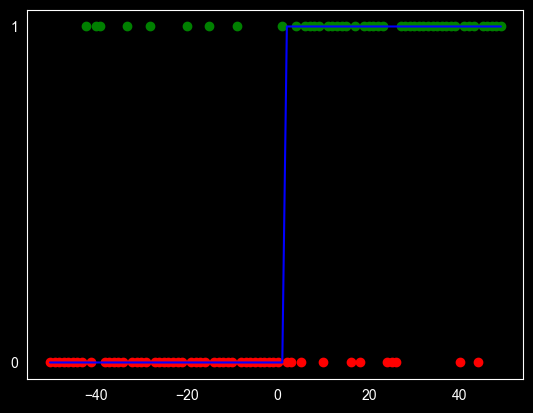

In [67]:
# Solve for Data 6
solve_by_grad_descent(X6, y6)

Slope : -0.1796   y-Intercept : -2.4367   Accuracy : 0.47   F1-Score : 0.3291


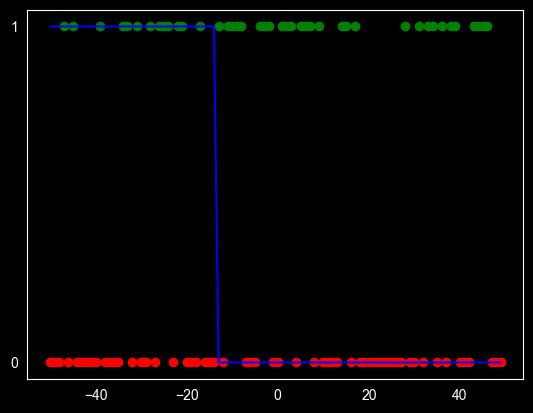

In [68]:
# Solve for Data 7
solve_by_grad_descent(X7, y7)

Slope : -3.6271   y-Intercept : -1.5376   Accuracy : 1.0   F1-Score : 1.0


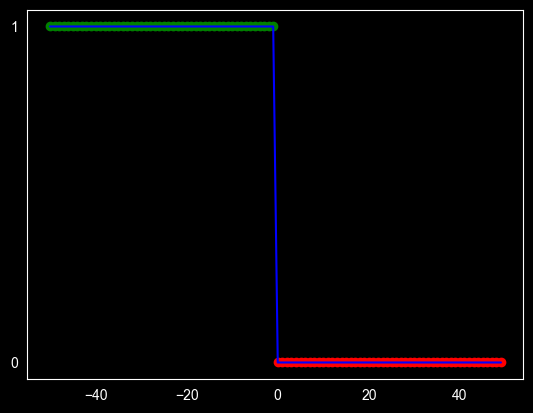

In [69]:
# Solve for Data 8
solve_by_grad_descent(X8, y8)

Slope : -0.2169   y-Intercept : 0.1085   Accuracy : 0.98   F1-Score : 0.9804


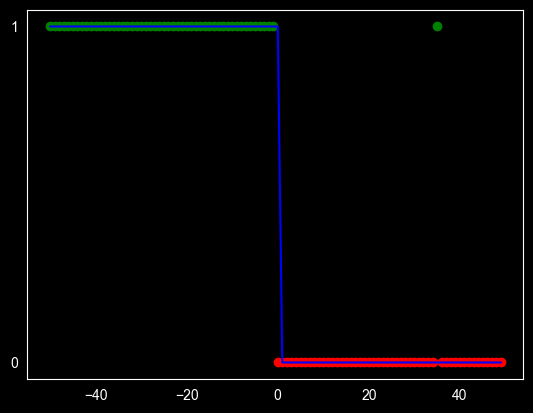

In [70]:
# Solve for Data 9
solve_by_grad_descent(X9, y9)

Slope : -0.1912   y-Intercept : -0.0956   Accuracy : 0.98   F1-Score : 0.98


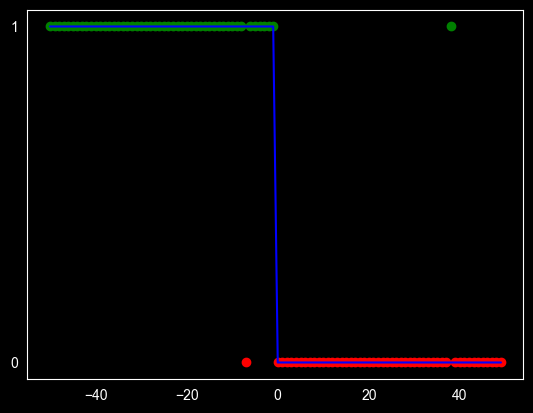

In [71]:
# Solve for Data 10
solve_by_grad_descent(X10, y10)

Slope : -0.1205   y-Intercept : -0.1813   Accuracy : 0.94   F1-Score : 0.9388


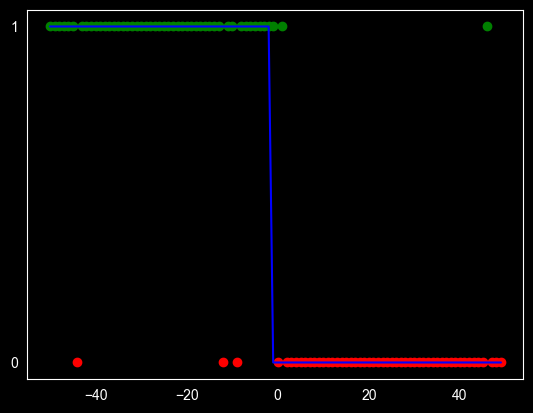

In [72]:
# Solve for Data 11
solve_by_grad_descent(X11, y11)

Slope : -0.1333   y-Intercept : -0.0524   Accuracy : 0.9   F1-Score : 0.9


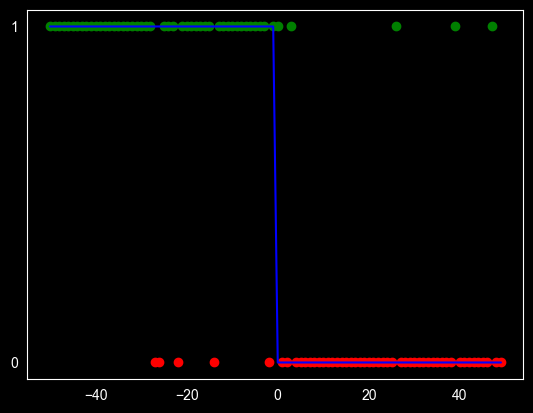

In [73]:
# Solve for Data 12
solve_by_grad_descent(X12, y12)

Slope : -1.206   y-Intercept : -0.6811   Accuracy : 0.8   F1-Score : 0.7959


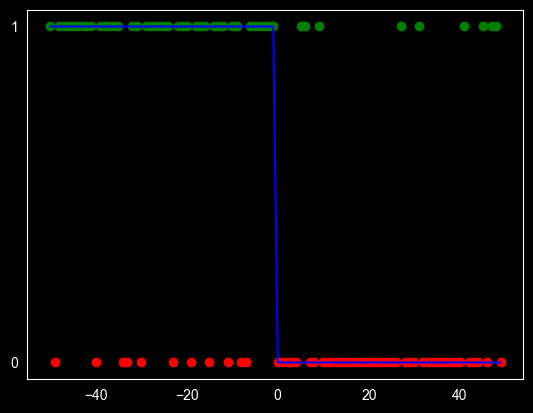

In [74]:
# Solve for Data 13
solve_by_grad_descent(X13, y13)

Slope : -0.1204   y-Intercept : -0.4346   Accuracy : 0.49   F1-Score : 0.4631


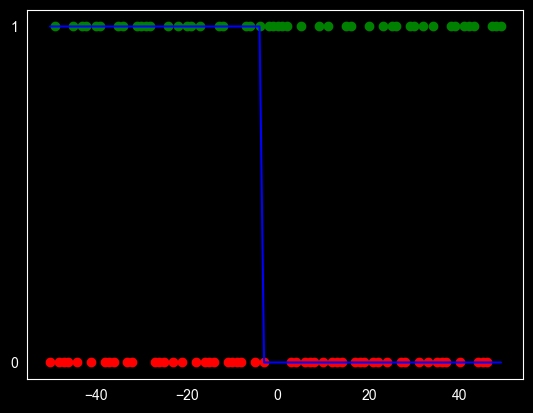

In [75]:
# Solve for Data 14
solve_by_grad_descent(X14, y14)

### Solve by SkLearn

In [76]:
from sklearn.linear_model import LogisticRegression
def get_model(X, y):
    model = LogisticRegression(random_state=42)
    model.fit(X, y)
    return model.intercept_[0], model.coef_[0][0], model

In [77]:
from sklearn.metrics import accuracy_score, f1_score

def solve_by_sklearn(x, y):
    x_b = x.reshape(-1, 1)
    c, m, model = get_model(x_b, y)
    y_pred = model.predict(x_b)
    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    print(f"Slope :", round(m, 4), "  y-Intercept :", round(c, 4),
          "  Accuracy :", acc, "  F1-Score :", f1, )
    plot(x, y, m, c)

Slope : 1.186   y-Intercept : 0.593   Accuracy : 1.0   F1-Score : 1.0


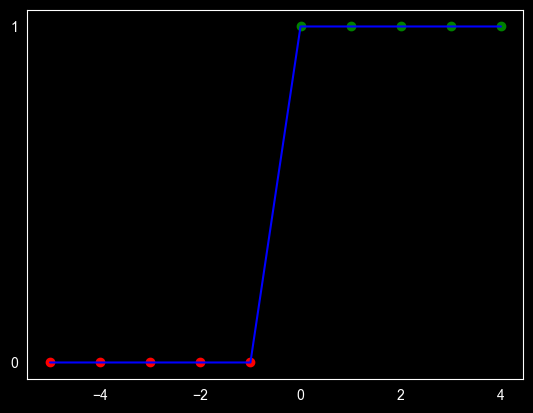

In [78]:
# Solve for Data 1
solve_by_sklearn(X1, y1)

Slope : 0.1929   y-Intercept : 0.2894   Accuracy : 0.98   F1-Score : 0.9803921568627451


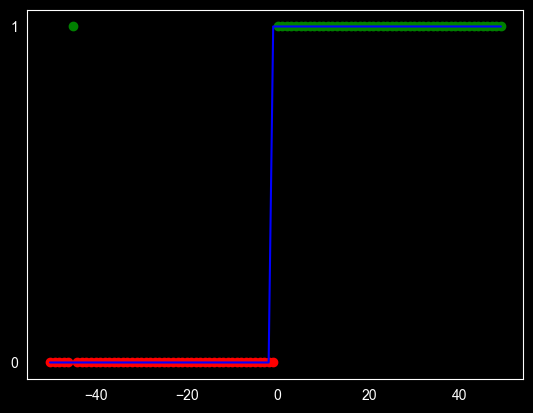

In [79]:
# Solve for Data 2
solve_by_sklearn(X2, y2)

Slope : 0.2132   y-Intercept : 0.1068   Accuracy : 0.98   F1-Score : 0.98


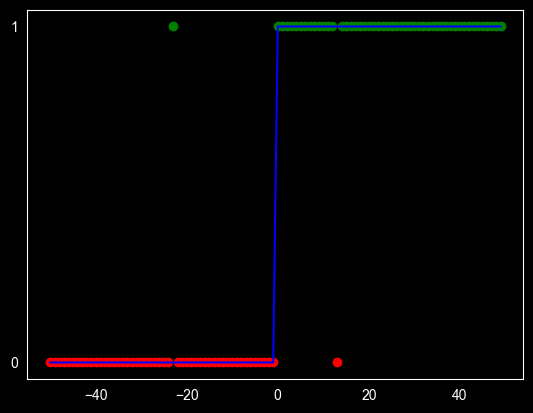

In [80]:
# Solve for Data 3
solve_by_sklearn(X3, y3)

Slope : 0.1259   y-Intercept : 0.1894   Accuracy : 0.96   F1-Score : 0.9607843137254902


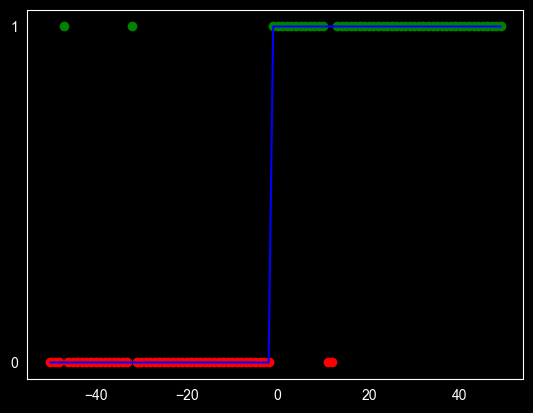

In [81]:
# Solve for Data 4
solve_by_sklearn(X4, y4)

Slope : 0.0655   y-Intercept : 0.174   Accuracy : 0.88   F1-Score : 0.8846153846153846


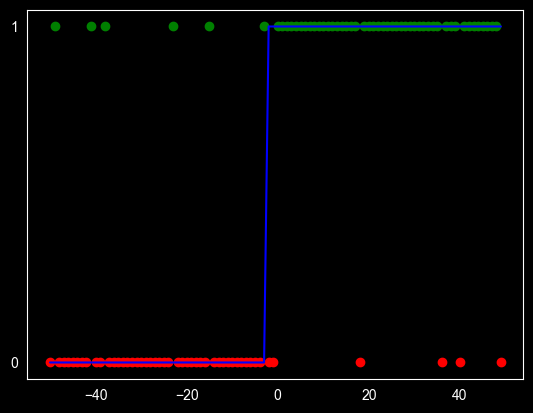

In [82]:
# Solve for Data 5
solve_by_sklearn(X5, y5)

Slope : 0.05   y-Intercept : -0.2112   Accuracy : 0.81   F1-Score : 0.7912087912087912


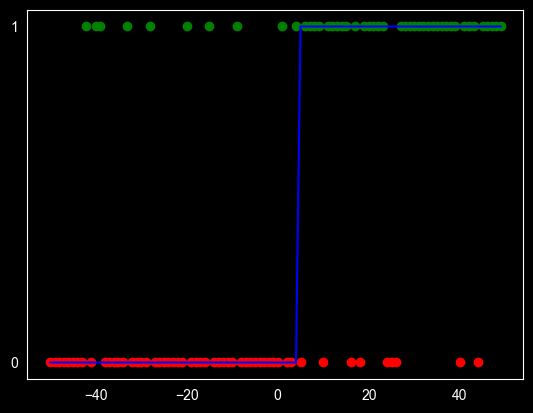

In [83]:
# Solve for Data 6
solve_by_sklearn(X6, y6)

Slope : 0.0032   y-Intercept : -0.3219   Accuracy : 0.58   F1-Score : 0.0


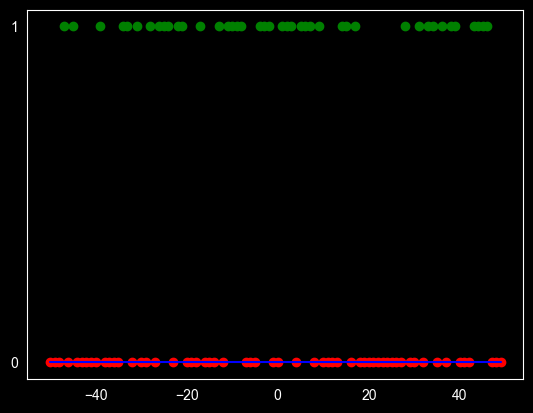

In [84]:
# Solve for Data 7
solve_by_sklearn(X7, y7)

Slope : -1.1951   y-Intercept : -0.5984   Accuracy : 1.0   F1-Score : 1.0


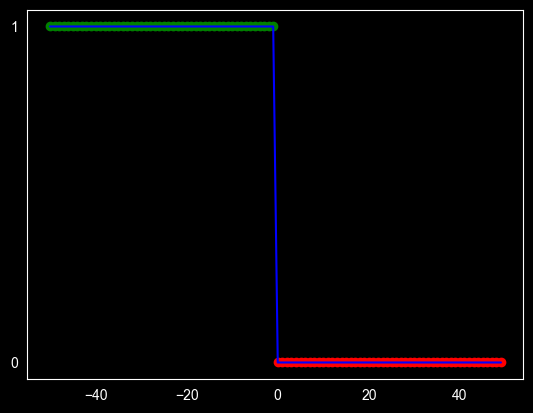

In [85]:
# Solve for Data 8
solve_by_sklearn(X8, y8)

Slope : -0.2162   y-Intercept : 0.1082   Accuracy : 0.98   F1-Score : 0.9803921568627451


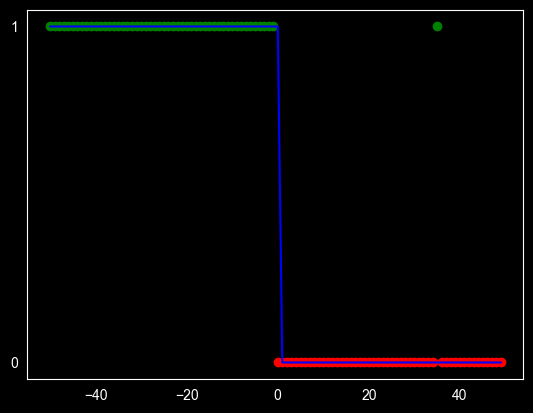

In [86]:
# Solve for Data 9
solve_by_sklearn(X9, y9)

Slope : -0.1908   y-Intercept : -0.0955   Accuracy : 0.98   F1-Score : 0.98


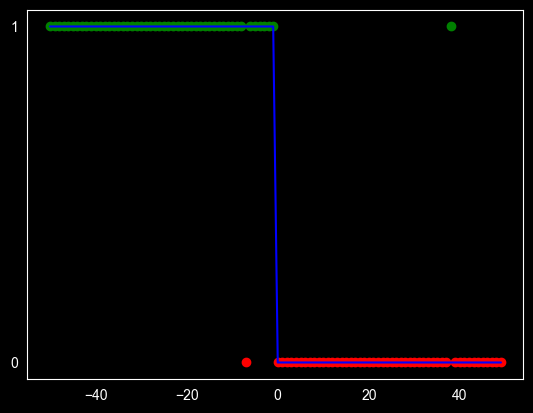

In [87]:
# Solve for Data 10
solve_by_sklearn(X10, y10)

Slope : -0.1204   y-Intercept : -0.1815   Accuracy : 0.94   F1-Score : 0.9387755102040817


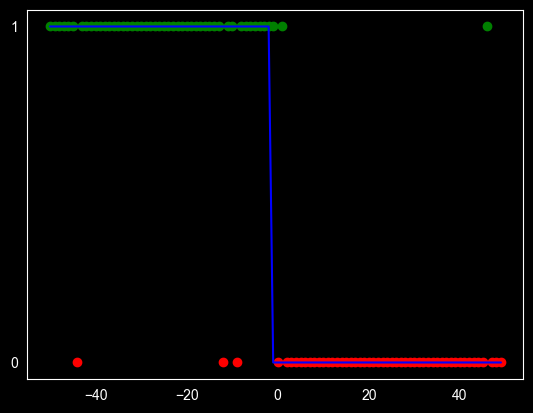

In [88]:
# Solve for Data 11
solve_by_sklearn(X11, y11)

Slope : -0.0853   y-Intercept : -0.0426   Accuracy : 0.9   F1-Score : 0.9


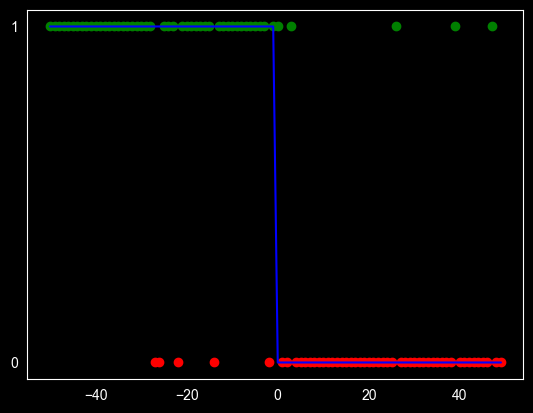

In [89]:
# Solve for Data 12
solve_by_sklearn(X12, y12)

Slope : -0.0417   y-Intercept : -0.128   Accuracy : 0.77   F1-Score : 0.7578947368421053


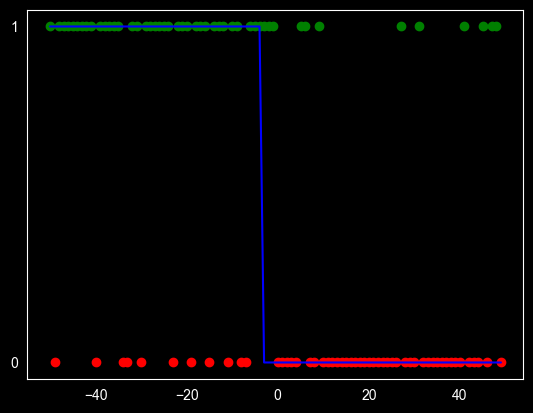

In [90]:
# Solve for Data 13
solve_by_sklearn(X13, y13)

Slope : 0.0027   y-Intercept : -0.079   Accuracy : 0.55   F1-Score : 0.34782608695652173


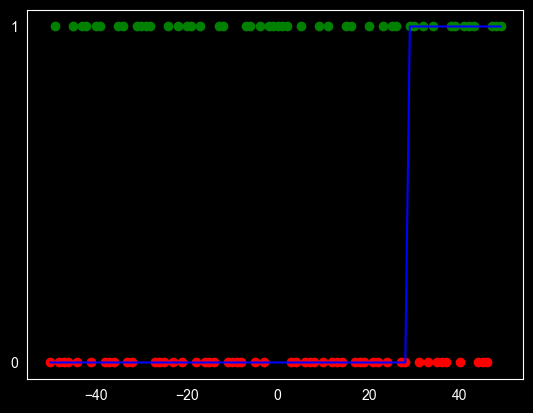

In [91]:
# Solve for Data 14
solve_by_sklearn(X14, y14)

End